In [1]:
from pathlib import Path
import shutil
import os

PROJECT_ROOT = Path.cwd()             
DATA_ROOT = PROJECT_ROOT / "data"      # local dataset folder
RUNS_ROOT = PROJECT_ROOT / "runs"

print("Project root:", PROJECT_ROOT)
print("Data root:", DATA_ROOT)
print("Runs root:", RUNS_ROOT)

assert DATA_ROOT.exists(), f"Dataset folder not found: {DATA_ROOT}"

Project root: c:\Users\youch\OneDrive - Cal Poly Pomona\CS4210 Spring 2026\Fire-Smoke-Detection
Data root: c:\Users\youch\OneDrive - Cal Poly Pomona\CS4210 Spring 2026\Fire-Smoke-Detection\data
Runs root: c:\Users\youch\OneDrive - Cal Poly Pomona\CS4210 Spring 2026\Fire-Smoke-Detection\runs


In [2]:
%%writefile data.yaml
path: .
train: data/train/images
val: data/val/images
test: data/test/images

names:
  0: smoke
  1: fire

Writing data.yaml


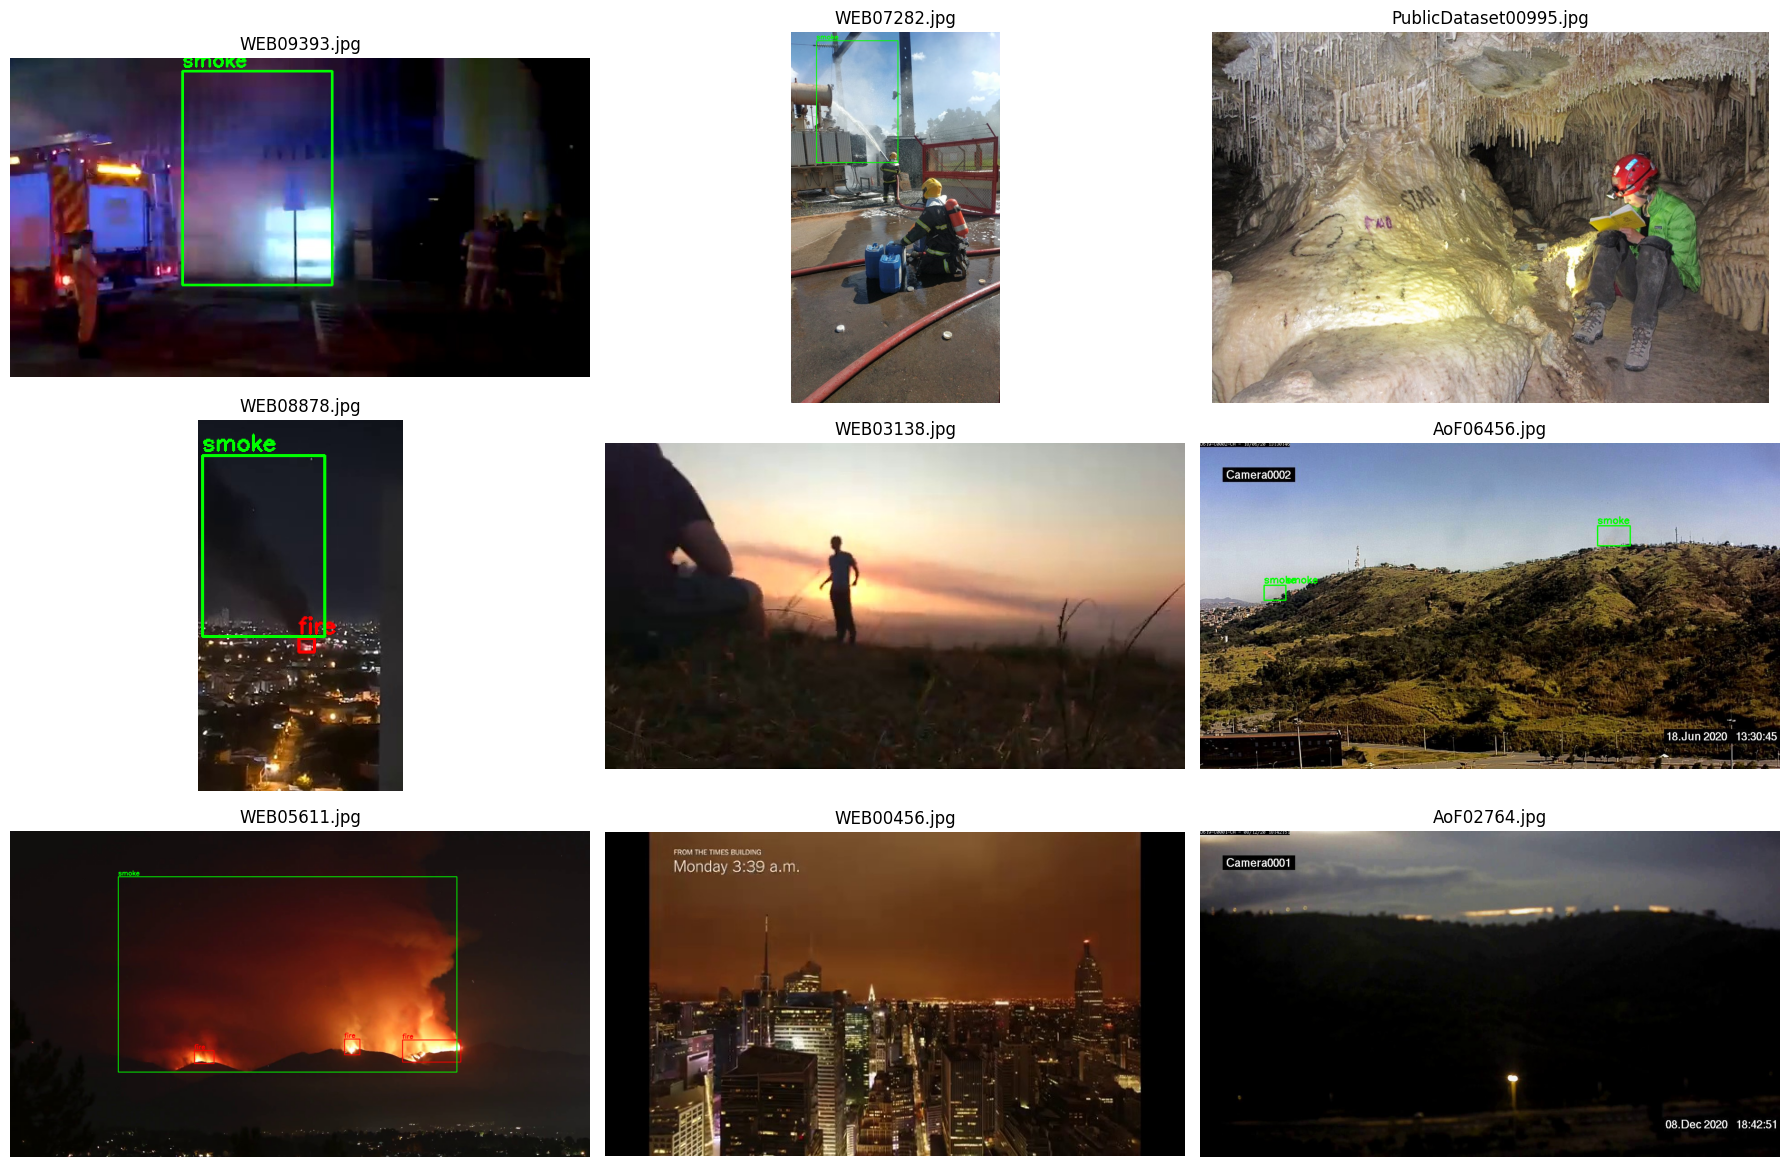

In [6]:
import random 
from matplotlib import pyplot as plt
import cv2

train_img_path = DATA_ROOT / "train/images"
train_label_path = DATA_ROOT / "train/labels"

sample_imgs = random.sample(os.listdir(train_img_path), 9)

def plot_image_with_boxes(img_path, label_path):
    img = cv2.imread(img_path)
    h, w, _ = img.shape
    label_file = label_path.replace('.jpg', '.txt').replace('.png', '.txt')
    if os.path.exists(label_file):
        with open(label_file, "r") as f:
            for line in f.readlines():
                cls, x_center, y_center, bw, bh = map(float, line.strip().split())
                x1 = int((x_center - bw/2) * w)
                y1 = int((y_center - bh/2) * h)
                x2 = int((x_center + bw/2) * w)
                y2 = int((y_center + bh/2) * h)
                color = (0, 255, 0) if cls == 0 else (0, 0, 255)
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                cls_name = "smoke" if cls == 0 else "fire"
                cv2.putText(img, cls_name, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

plt.figure(figsize=(18, 12))
for i, img_name in enumerate(sample_imgs):
    img_path = os.path.join(train_img_path, img_name)
    label_path = os.path.join(train_label_path, img_name)
    plt.subplot(3, 3, i+1)
    plt.imshow(plot_image_with_boxes(img_path, label_path))
    plt.axis('off')
    plt.title(img_name)
plt.tight_layout()
plt.show()


In [7]:
# Checking for paired images and labels

missing_labels = []
missing_images = []

image_bases = {os.path.splitext(f)[0] for f in os.listdir(train_img_path)}
label_bases = {os.path.splitext(f)[0] for f in os.listdir(train_label_path)}

for base in image_bases:
    if base not in label_bases:
        missing_labels.append(base)

for base in label_bases:
    if base not in image_bases:
        missing_images.append(base)

print("Images without labels:", len(missing_labels))
print("Labels without images:", len(missing_images))



Images without labels: 0
Labels without images: 0


In [8]:
def validate_yolo_labels(label_dir, valid_classes=[0, 1], verbose=True):
    bad_labels = []

    for fname in os.listdir(label_dir):
        if not fname.endswith(".txt"):
            continue

        path = os.path.join(label_dir, fname)
        with open(path, "r") as f:
            lines = f.readlines()

        for i, line in enumerate(lines, start=1):
            parts = line.strip().split()

            if len(parts) != 5:
                bad_labels.append((fname, i, "wrong number of fields"))
                continue

            try:
                cls = int(parts[0])
                x, y, w, h = map(float, parts[1:])
            except ValueError:
                bad_labels.append((fname, i, "non-numeric value"))
                continue

            if cls not in valid_classes:
                bad_labels.append((fname, i, f"invalid class {cls}"))

            if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
                bad_labels.append((fname, i, "bbox out of range"))

    if verbose:
        print("Bad label entries:", len(bad_labels))
        if len(bad_labels) > 0:
            print("Sample:", bad_labels[:10])

    return bad_labels

bad_labels = validate_yolo_labels(train_label_path)

Bad label entries: 13
Sample: [('AoF05470.txt', 2, 'bbox out of range'), ('AoF06155.txt', 2, 'bbox out of range'), ('AoF06348.txt', 2, 'bbox out of range'), ('AoF06439.txt', 2, 'bbox out of range'), ('AoF06456.txt', 2, 'bbox out of range'), ('PublicDataset00056.txt', 5, 'bbox out of range'), ('WEB04243.txt', 5, 'bbox out of range'), ('WEB04527.txt', 2, 'bbox out of range'), ('WEB04742.txt', 5, 'bbox out of range'), ('WEB04849.txt', 5, 'bbox out of range')]


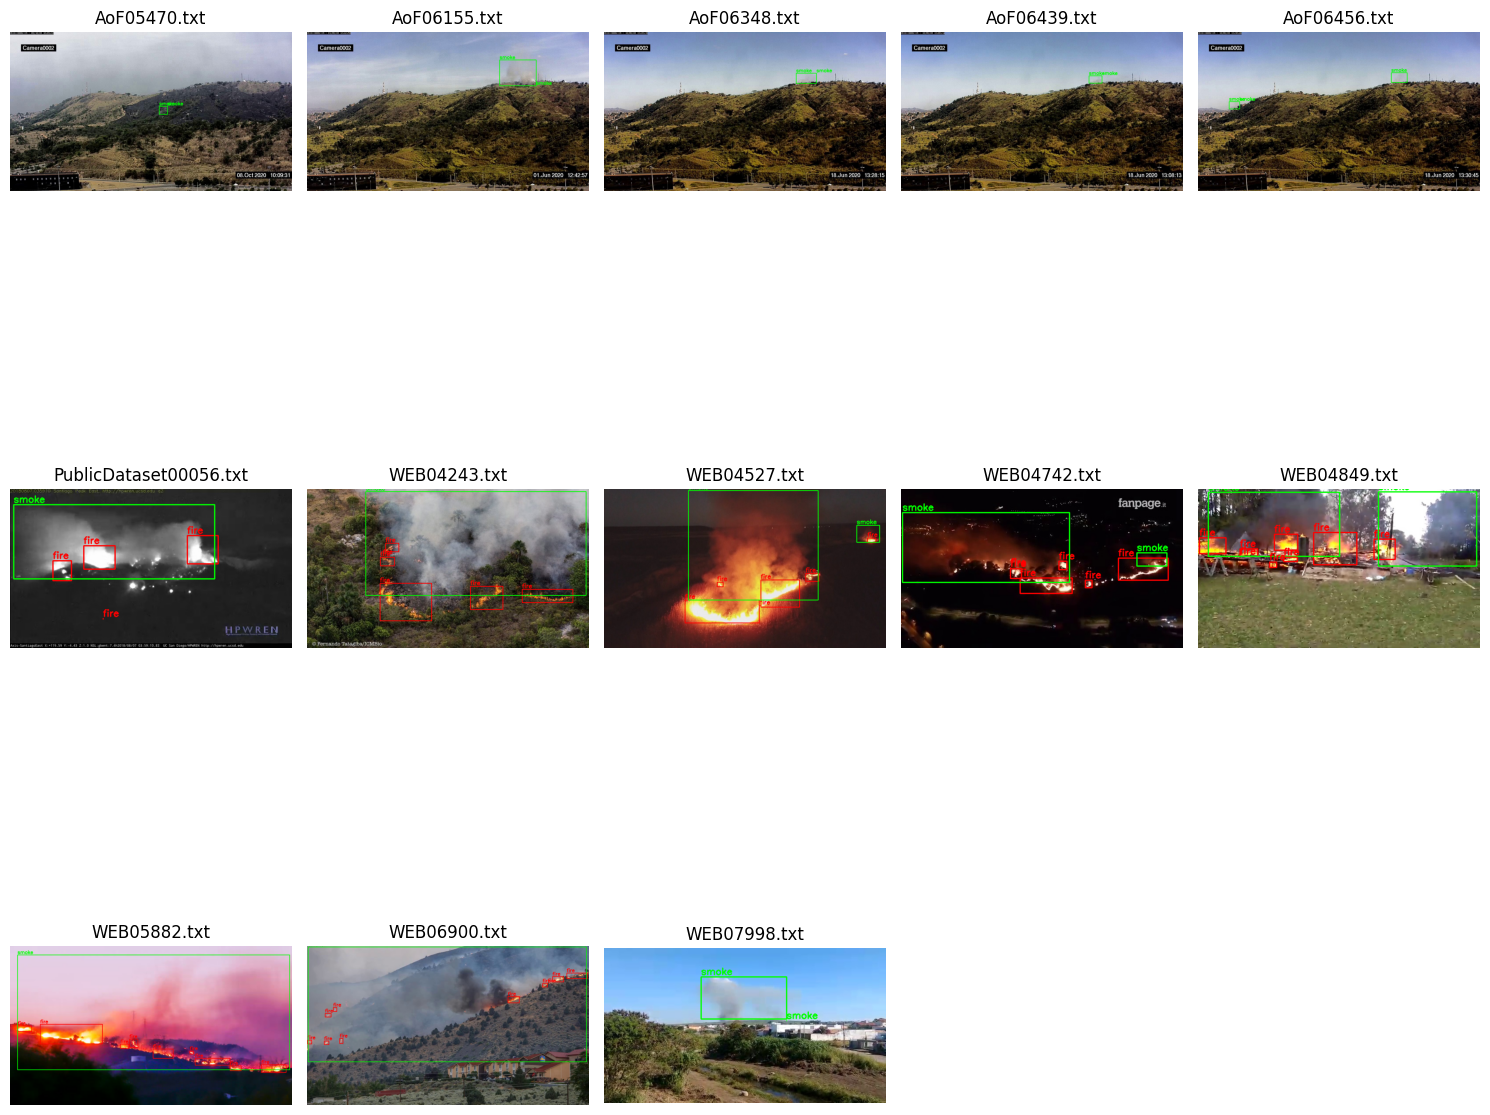

In [9]:
# Visualize some of the bad labels

plt.figure(figsize=(15, 15))

for i, (fname, line_no, reason) in enumerate(bad_labels[:13], start=1):
    label_path = os.path.join(train_label_path, fname)

    base = os.path.splitext(fname)[0]
    img_path = None
    for ext in [".jpg", ".png", ".jpeg"]:
        candidate = os.path.join(train_img_path, base + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break

    if img_path is None:
        print(f"Image not found for {fname}")
        continue

    img = plot_image_with_boxes(img_path, label_path)
    if img is None:
        continue

    plt.subplot(3, 5, i)
    plt.imshow(img)
    plt.title(f"{fname}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# Clean up the bad bounding boxes:
# Clip the bounding box to between 0,1

bad_lookup = {(fname, line_no) for fname, line_no, _ in bad_labels}

for fname in os.listdir(train_label_path):
    if not fname.endswith(".txt"):
        continue

    path = os.path.join(train_label_path, fname)
    with open(path, "r") as f:
        lines = f.readlines()

    updated_lines = []

    for i, line in enumerate(lines, start=1):
        parts = line.strip().split()

        if len(parts) != 5:
            updated_lines.append(line)
            continue

        try:
            cls = int(parts[0])
            x, y, w, h = map(float, parts[1:])
        except ValueError:
            updated_lines.append(line)
            continue

        if (fname, i) in bad_lookup:
            x = min(max(x, 0.0), 1.0)
            y = min(max(y, 0.0), 1.0)
            w = min(max(w, 1e-6), 1.0)
            h = min(max(h, 1e-6), 1.0)
            updated_lines.append(f"{cls} {x} {y} {w} {h}\n")
        else:
            updated_lines.append(line)

    with open(path, "w") as f:
        f.writelines(updated_lines)

print("Clipped only the bad entries.")
bad_labels_after = validate_yolo_labels(train_label_path)

Clipped only the bad entries.
Bad label entries: 0


In [11]:
# check for class distribution 

from collections import Counter
import os

counter = Counter()

for fname in os.listdir(train_label_path):
    if not fname.endswith(".txt"):
        continue

    path = os.path.join(train_label_path, fname)
    with open(path, "r") as f:
        lines = f.readlines()
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        try:
            cls = int(parts[0])
            counter[cls] += 1
        except ValueError:
            continue
print("Class distribution:", counter)

Class distribution: Counter({1: 9638, 0: 7794})


In [12]:
from ultralytics import YOLO
import torch
from pathlib import Path

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

assert Path("data.yaml").exists(), "data.yaml not found"
assert Path("data/train/images").exists(), "train images folder missing"
assert Path("data/val/images").exists(), "val images folder missing"

model = YOLO("yolo11n.pt")

model.train(
    data="data.yaml",
    epochs=80,
    imgsz=640,
    batch=32,
    device=0,
    workers=8,
    cache=True,
    project="runs/detect",
    name="yolo11_fire_smoke",
    patience=20,
    mosaic=0.5,
    mixup=0.1,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
)



CUDA available: False


KeyboardInterrupt: 

In [ ]:
best_model = YOLO("runs/detect/yolo11_fire_smoke/weights/best.pt")
metrics = best_model.val(data="data.yaml")
print(metrics)

best_model.predict(
    source="data/test/images",
    conf=0.25,
    save=True,
    project="runs/predict",
    name="fire_smoke_test"
)